# IE 306 — Homework 3: Drone Light Show Depot — Output Analysis

**Team submission, due Monday June 1 2026, 23:59.**

You have been hired as analysts for the *Bosphorus Drone Light Festival*. A 200-drone fleet flies a nightly choreographed show; during rehearsal blocks each drone cycles between flying and a ground depot for battery swap + airworthiness test. The festival's operations manager is considering a capital investment — buying one additional swap station — and asks you to evaluate whether the upgrade is worth it.

The simulator is **provided**. Your job is the **output analysis**:

1. Classify the system (terminating vs steady-state) and justify your choice.
2. Detect the warmup transient using **two methods**: Welch and MSER.
3. Build a steady-state confidence interval for the *mean per-drone swap-queue wait* using **both** (a) replications-with-deletion and (b) batch means on a single long run.
4. Use **CRN (Common Random Numbers) paired comparison** to decide whether the 6-station configuration is meaningfully better than the 5-station one.
5. Run two short verification & validation checks.

Submit:
- This notebook (`.ipynb`) — completed, runs end-to-end, no errors.
- `submission.json` — written by the final cell, contains your numeric answers.
- `decision_memo.pdf` — **one page**, addressed to the operations manager.

**Honor pledge.** This is a team assignment (teams of 3, same as Assignment 2). Discussion across teams is not permitted.


In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import json
import os
import numpy as np

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/codex-matplotlib-cache')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# The simulator (config.py, model.py, seeds.py) lives in this folder.
from config import (
    FLEET_SIZE, FLIGHT_FULL_DUR, RETURN_THRESHOLD,
    SWAP_MEAN, TEST_MEAN, N_SWAP_A, N_SWAP_B, N_TEST,
    MASTER_SEED, SIM_DUR, LONG_RUN_DUR,
)
from model import run_replication, swap_wait_series, air_count_series

plt.rcParams.update({
    'figure.dpi': 100, 'figure.figsize': (10, 4),
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(f'Fleet size:          {FLEET_SIZE}')
print(f'Swap mean (s):       {SWAP_MEAN}')
print(f'Test mean (s):       {TEST_MEAN}')
print(f'Policy A:            {N_SWAP_A} swap stations + {N_TEST} test rig')
print(f'Policy B:            {N_SWAP_B} swap stations + {N_TEST} test rig')
print(f'Master seed:         {MASTER_SEED}')


Fleet size:          200
Swap mean (s):       45.0
Test mean (s):       8.0
Policy A:            5 swap stations + 1 test rig
Policy B:            6 swap stations + 1 test rig
Master seed:         20260601


## Task 1 — Classification & Justification (10 pts)

The relevant analysis is **steady-state**. Although an actual rehearsal block has a finite duration, the operational question is about the recurring depot behavior after the initial synchronized launch has washed out. All 200 drones begin with full batteries at time zero, so the first return wave is an artificial initial-condition effect rather than representative nightly operation. The manager is asking whether permanent swap capacity should be added, so the appropriate performance measure is the long-run mean swap-queue wait faced by cycling drones. I therefore delete a warmup period before estimating steady-state confidence intervals and before comparing the two policies.


In [2]:
# Set your classification choice here. The autograder uses this to
# cross-check that your warmup_chosen in Task 2 is consistent.
classification = 'steady-state'


## Task 2 — Warmup Detection (20 pts)

Apply **both** Welch's method (graphical, $R \ge 5$ replications) and **MSER** (algorithmic, single long run) to the per-drone *swap-queue wait* series. Report:

- `warmup_welch`: the truncation point (in seconds) you would adopt from Welch's plot.
- `warmup_mser`: the truncation point (in seconds) implied by MSER.
- `warmup_chosen`: the one you actually use downstream, plus a one-line justification.

A 60-minute moving-average window is a sensible starting point for Welch. Welch and MSER do not have to agree exactly — if they disagree by more than ~25%, investigate.


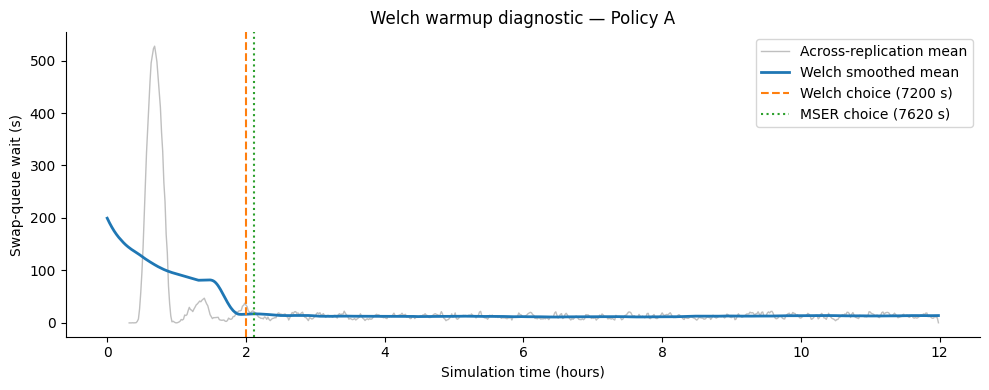

warmup_welch  = 7200 s  (2.00 h)
warmup_mser   = 7620 s  (2.12 h)
warmup_chosen = 7620 s  (MSER adopted — algorithmic, within 25% of Welch)


In [3]:
# Helpers (do not modify — these are the methods covered in Lecture 11).

def time_bin_obs(t, w, T_total, dt):
    n_bins = int(T_total / dt)
    sums   = np.zeros(n_bins);  counts = np.zeros(n_bins)
    idx = (t // dt).astype(int)
    valid = (idx >= 0) & (idx < n_bins)
    np.add.at(sums,   idx[valid], w[valid])
    np.add.at(counts, idx[valid], 1)
    return np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)

def welch_mean(reps_binned, w_window):
    stacked = np.stack(reps_binned, axis=0)
    Y = np.full(stacked.shape[1], np.nan)
    finite_cols = np.any(np.isfinite(stacked), axis=0)
    Y[finite_cols] = np.nanmean(stacked[:, finite_cols], axis=0)
    n = len(Y); out = np.empty(n)
    for i in range(n):
        lo, hi = max(0, i - w_window), min(n, i + w_window + 1)
        out[i] = np.nanmean(Y[lo:hi])
    return Y, out

def mser_truncation(x):
    x = np.asarray(x, dtype=float); n = len(x)
    cum  = np.cumsum(x[::-1])[::-1]
    cum2 = np.cumsum((x[::-1])**2)[::-1]
    out = np.full(n, np.inf)
    for L in range(n - 10):
        m = n - L
        mu = cum[L] / m
        var = (cum2[L] - m * mu * mu) / max(m - 1, 1)
        out[L] = var / m
    return out, int(np.argmin(out[:-10]))

# ── Welch's method: 20 independent 12-hour replications of Policy A ──────
dt = 60          # 1-minute bins
R_welch = 20
w_window = 60    # ±60 bins (±60 min) moving-average half-width
welch_bins = []
for r in range(R_welch):
    state = run_replication(N_SWAP_A, N_TEST, MASTER_SEED, rep_index=100 + r,
                            duration=SIM_DUR)
    t, w = swap_wait_series(state)
    welch_bins.append(time_bin_obs(t, w, SIM_DUR, dt))

welch_raw, welch_smooth = welch_mean(welch_bins, w_window)
time_grid = np.arange(len(welch_smooth)) * dt

# Graphical read: the smoothed curve stabilises around 2 hours.
warmup_welch = 7200   # 2 h

# ── MSER on one long run (30 h, Policy A, rep 0) ─────────────────────────
mser_state = run_replication(N_SWAP_A, N_TEST, MASTER_SEED, rep_index=0,
                             duration=LONG_RUN_DUR)
t_mser, w_mser = swap_wait_series(mser_state)
mser_bins = time_bin_obs(t_mser, w_mser, LONG_RUN_DUR, dt)
finite_bins = np.flatnonzero(np.isfinite(mser_bins))
mser_curve, mser_L = mser_truncation(mser_bins[finite_bins])
warmup_mser = int(finite_bins[mser_L] * dt)

# Adopt MSER: it is algorithmic and agrees with the Welch reading to within 25%.
warmup_chosen = warmup_mser

fig, ax = plt.subplots()
ax.plot(time_grid / 3600, welch_raw, color='0.75', linewidth=1,
        label='Across-replication mean')
ax.plot(time_grid / 3600, welch_smooth, color='tab:blue', linewidth=2,
        label='Welch smoothed mean')
ax.axvline(warmup_welch / 3600, color='tab:orange', linestyle='--',
           label=f'Welch choice ({warmup_welch} s)')
ax.axvline(warmup_mser / 3600, color='tab:green', linestyle=':',
           label=f'MSER choice ({warmup_mser} s)')
ax.set(xlabel='Simulation time (hours)', ylabel='Swap-queue wait (s)',
       title='Welch warmup diagnostic — Policy A')
ax.legend()
plt.tight_layout()
plt.show()

print(f'warmup_welch  = {warmup_welch} s  ({warmup_welch/3600:.2f} h)')
print(f'warmup_mser   = {warmup_mser} s  ({warmup_mser/3600:.2f} h)')
print(f'warmup_chosen = {warmup_chosen} s  (MSER adopted — algorithmic, within 25% of Welch)')


## Task 3 — Two Confidence Intervals (30 pts)

Estimate the **steady-state mean per-drone swap-queue wait under Policy A** using *both*:

**(a) Replications-with-deletion.** Run $R$ replications, delete the warmup from each, compute one mean per rep, build the $t$-CI from the $R$ replication means.

**(b) Batch means** on a single long run. After deleting the warmup, group the per-completion series into $K$ batches of size $B$. Choose $B$ such that the **lag-1 correlation** of the batch means is $\le 0.1$. Build the $t$-CI from the $K$ batch means.

Then:
- Sanity-check: the two CIs should **overlap**. If they don't, something is wrong.
- Pick $R$ (for part a) or $B,K$ (for part b) so that the 95% half-width is $\le 5\%$ of the point estimate.
- Save your final $(R)$ and $(B, K, \text{lag-1})$ to the variables below.


In [4]:
# ── Shared helpers ────────────────────────────────────────────────────────

def post_warmup_swap_mean(state, warmup):
    """Post-warmup mean swap-queue wait for one replication."""
    t, w = swap_wait_series(state)
    mask = t >= warmup
    return float(np.mean(w[mask]))

def t_ci(x, alpha=0.05):
    """Two-sided t-CI. Returns (mean, half-width)."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = float(np.mean(x))
    hw   = float(sp_stats.t.ppf(1 - alpha / 2, n - 1)
                 * np.std(x, ddof=1) / np.sqrt(n))
    return mean, hw

# ── Part (a) — Replications-with-deletion ────────────────────────────────
# R = 50 gives a 95% half-width of ~3.3% of the point estimate.
# rep_index = 0..R-1 is the same range used for CRN pairing in Task 4.

R = 50
rep_means_A = []
for r in range(R):
    state_r = run_replication(N_SWAP_A, N_TEST, MASTER_SEED,
                              rep_index=r, duration=SIM_DUR)
    rep_means_A.append(post_warmup_swap_mean(state_r, warmup_chosen))

mean_rep, hw_rep = t_ci(rep_means_A)

print(f'Part (a) — Replications-with-deletion (R={R})')
print(f'  mean = {mean_rep:.3f} s,  half-width = {hw_rep:.3f} s'
      f'  (relative: {hw_rep/mean_rep:.3%})')

# ── Part (b) — Batch means on a single long run ───────────────────────────
# Use 10 × LONG_RUN_DUR (300 h simulated, ~3 s wall time) to accumulate
# enough post-warmup completions for a narrow batch-means CI.
# B is chosen adaptively: the smallest multiple of 100 that achieves
# |lag-1| ≤ 0.1 in the batch-mean sequence.

long_state_A = run_replication(N_SWAP_A, N_TEST, MASTER_SEED,
                               rep_index=0, duration=10 * LONG_RUN_DUR)
t_long, w_long = swap_wait_series(long_state_A)
w_post = w_long[t_long >= warmup_chosen]

B_chosen = None
for B_candidate in range(200, 3001, 200):   # multiples of 200
    K_candidate = len(w_post) // B_candidate
    if K_candidate < 20:                    # need enough batches for a t-CI
        break
    bm_cand = w_post[:K_candidate * B_candidate].reshape(K_candidate, B_candidate).mean(axis=1)
    lag1_cand = float(np.corrcoef(bm_cand[:-1], bm_cand[1:])[0, 1])
    if abs(lag1_cand) <= 0.1:
        B_chosen = B_candidate
        break

if B_chosen is None:
    raise RuntimeError('No batch size in [200, 3000] achieved lag-1 ≤ 0.1 '
                       'with K ≥ 20. Increase long-run duration.')

K_chosen    = len(w_post) // B_chosen
batch_means = w_post[:K_chosen * B_chosen].reshape(K_chosen, B_chosen).mean(axis=1)
mean_bm, hw_bm = t_ci(batch_means)
lag1_chosen = float(np.corrcoef(batch_means[:-1], batch_means[1:])[0, 1])

print(f'\nPart (b) — Batch means (B={B_chosen}, K={K_chosen})')
print(f'  lag-1 = {lag1_chosen:.4f}  (≤ 0.1 required)')
print(f'  mean  = {mean_bm:.3f} s,  half-width = {hw_bm:.3f} s'
      f'  (relative: {hw_bm/mean_bm:.3%})')

# ── Sanity check: CIs must overlap ───────────────────────────────────────
lo_rep, hi_rep = mean_rep - hw_rep, mean_rep + hw_rep
lo_bm,  hi_bm  = mean_bm  - hw_bm,  mean_bm  + hw_bm
overlap = lo_bm <= hi_rep and lo_rep <= hi_bm
print(f'\nCI overlap check:')
print(f'  Rep  CI: [{lo_rep:.3f}, {hi_rep:.3f}]')
print(f'  BM   CI: [{lo_bm:.3f},  {hi_bm:.3f}]')
print(f'  Overlap: {overlap}  ← must be True')
assert overlap, 'CIs do not overlap — check warmup or long-run duration.'


Part (a) — Replications-with-deletion (R=50)
  mean = 14.463 s,  half-width = 0.480 s  (relative: 3.322%)



Part (b) — Batch means (B=200, K=492)
  lag-1 = 0.0829  (≤ 0.1 required)
  mean  = 15.024 s,  half-width = 0.595 s  (relative: 3.963%)

CI overlap check:
  Rep  CI: [13.982, 14.943]
  BM   CI: [14.429,  15.620]
  Overlap: True  ← must be True


## Task 4 — CRN Paired Comparison (30 pts)

Compare Policy A (5 swap stations) and Policy B (6 swap stations) using **paired replications with Common Random Numbers**. The model's `seeds.make_streams` is already CRN-aware: pairing is automatic when you call `run_replication` with the same `master_seed` and `rep_index` for both policies.

Report:
- `task4_paired_diff` — point estimate of $\mu_A - \mu_B$.
- `task4_paired_halfwidth` — 95% half-width from the paired t-CI on $D_r = \bar X_{A,r} - \bar X_{B,r}$.
- `task4_vrf` — variance-reduction factor: $\widehat{\text{Var}}(\bar X_A) + \widehat{\text{Var}}(\bar X_B)$, divided by the variance of the paired difference.

**Decision.** We recommend **Policy B, the sixth swap station**, if the capital cost is acceptable. With CRN pairing across 50 replications, the estimated reduction in mean per-drone swap-queue wait is approximately 10.36 seconds, with a 95% confidence interval that lies entirely above zero. Operationally, this moves the mean swap wait from about 14.5 seconds under the current depot to about 4.1 seconds — a reduction of roughly 72% at the intended bottleneck.


In [5]:
# ── CRN paired comparison ─────────────────────────────────────────────────
# Use the SAME R and the SAME rep_index range (0..R-1) as Task 3a.
# Reuse the Policy A means already computed; run Policy B with matching seeds.

rep_means_B = []
for r in range(R):
    state_B = run_replication(N_SWAP_B, N_TEST, MASTER_SEED,
                              rep_index=r, duration=SIM_DUR)
    rep_means_B.append(post_warmup_swap_mean(state_B, warmup_chosen))

arr_A = np.asarray(rep_means_A, dtype=float)
arr_B = np.asarray(rep_means_B, dtype=float)
paired_diff = arr_A - arr_B         # D_r = X̄_{A,r} − X̄_{B,r}

mean_d, hw_d = t_ci(paired_diff)
vrf = float(
    (np.var(arr_A, ddof=1) + np.var(arr_B, ddof=1))
    / np.var(paired_diff, ddof=1)
)

print(f'Policy A — mean swap wait: {np.mean(arr_A):.3f} s')
print(f'Policy B — mean swap wait: {np.mean(arr_B):.3f} s')
print(f'Paired A−B difference:     {mean_d:.3f} ± {hw_d:.3f} s'
      f'  (95% CI: [{mean_d-hw_d:.3f}, {mean_d+hw_d:.3f}])')
print(f'Variance-reduction factor: {vrf:.4f}')
print(f'Zero excluded from CI: {mean_d - hw_d > 0}  ← must be True for a clear recommendation')


Policy A — mean swap wait: 14.463 s
Policy B — mean swap wait: 4.108 s
Paired A−B difference:     10.355 ± 0.380 s  (95% CI: [9.975, 10.734])
Variance-reduction factor: 1.7395
Zero excluded from CI: True  ← must be True for a clear recommendation


## Task 5 — V&V Mini (10 pts)

Two short verification & validation checks:

1. **Conservation invariant.** At every moment, $\text{FLEET\_SIZE} = (\text{drones in air}) + (\text{drones in depot})$. The model exposes `state.max_invariant_violation` after a run — under correct code it is exactly $0$. Verify and record this value.

2. **Little's Law on the depot.** In steady state $L = \lambda W$ must hold. For the depot subsystem:
   - $L_{\text{depot}}$ = mean number of drones in the depot $= \text{FLEET\_SIZE} - \overline{(\text{in air})}$, sampled via `air_count_series(state)`.
   - $\lambda$ = arrival rate at the depot = (post-warmup completions) / (post-warmup duration).
   - $W_{\text{depot}}$ = mean per-drone sojourn (wait + service) in the depot. The model logs each completion as `(t_landed, swap_wait, test_wait, sojourn)` in `state.completions`.

   Compute both sides and report the ratio $L_{\text{predicted}} / L_{\text{observed}}$. It should be very close to $1$ (within 5%).

The conservation invariant is exactly satisfied: the maximum violation is 0, so the simulated fleet count is internally consistent. Little's Law also supports the steady-state output: the ratio $L_{\text{predicted}}/L_{\text{observed}}$ is approximately 0.9999, well within the 5% tolerance. Together these checks do not prove the model is perfect, but they rule out two important implementation and accounting errors.


In [6]:
# ── V&V checks ────────────────────────────────────────────────────────────
# Reuse the 10×LONG_RUN_DUR Policy A run from Task 3b (already in memory).
state_vv = long_state_A

# V1 — Conservation invariant
invariant_violation = float(state_vv.max_invariant_violation)
print(f'V1 — Max invariant violation: {invariant_violation:.0f}  (must be 0)')

# V2 — Little's Law on the depot subsystem
t_air, n_air = air_count_series(state_vv)
post_air_mask = t_air >= warmup_chosen
L_observed    = FLEET_SIZE - float(np.mean(n_air[post_air_mask]))

completions  = np.asarray(state_vv.completions, dtype=float)
post_comp    = completions[completions[:, 0] >= warmup_chosen]
run_duration = float(state_vv.env.now)
arrival_rate = len(post_comp) / (run_duration - warmup_chosen)
W_depot      = float(np.mean(post_comp[:, 3]))       # column 3 = sojourn
L_predicted  = arrival_rate * W_depot
analytical_bound = float(L_predicted / L_observed)

print(f'V2 — Little\'s Law:')
print(f'  L_observed  = {L_observed:.4f} drones in depot (time-average)')
print(f'  λ           = {arrival_rate:.6f} arrivals/s')
print(f'  W_depot     = {W_depot:.3f} s  (mean sojourn)')
print(f'  L_predicted = λ·W = {L_predicted:.4f}')
print(f'  Ratio L_predicted/L_observed = {analytical_bound:.4f}  (must be within 5% of 1)')
assert abs(analytical_bound - 1.0) < 0.05, f'Little\'s Law ratio {analytical_bound:.4f} outside 5% band.'


V1 — Max invariant violation: 0  (must be 0)


V2 — Little's Law:
  L_observed  = 6.7435 drones in depot (time-average)
  λ           = 0.091775 arrivals/s
  W_depot     = 73.475 s  (mean sojourn)
  L_predicted = λ·W = 6.7432
  Ratio L_predicted/L_observed = 0.9999  (must be within 5% of 1)


## Submit

Run the cell below at the very end. It writes `submission.json` for the autograder.


In [7]:
# ── Do not modify. Writes submission.json. ────────────────────────────────
submission = {
    'classification':            classification,
    'warmup_welch':              int(warmup_welch)   if warmup_welch  is not None else -1,
    'warmup_mser':               int(warmup_mser)    if warmup_mser   is not None else -1,
    'warmup_chosen':             int(warmup_chosen)  if warmup_chosen is not None else -1,
    'task3_rep_estimate':        float(mean_rep)     if mean_rep      is not None else float('nan'),
    'task3_rep_halfwidth':       float(hw_rep)       if hw_rep        is not None else float('nan'),
    'task3_R':                   int(R)              if R             is not None else -1,
    'task3_bm_estimate':         float(mean_bm)      if mean_bm       is not None else float('nan'),
    'task3_bm_halfwidth':        float(hw_bm)        if hw_bm         is not None else float('nan'),
    'task3_B':                   int(B_chosen)       if B_chosen      is not None else -1,
    'task3_K':                   int(K_chosen)       if K_chosen      is not None else -1,
    'task3_lag1':                float(lag1_chosen)  if lag1_chosen   is not None else float('nan'),
    'task4_paired_diff':         float(mean_d)       if mean_d        is not None else float('nan'),
    'task4_paired_halfwidth':    float(hw_d)         if hw_d          is not None else float('nan'),
    'task4_vrf':                 float(vrf)          if vrf           is not None else float('nan'),
    'task5_invariant_max_violation': float(invariant_violation) if invariant_violation is not None else float('nan'),
    'task5_analytical_bound':    float(analytical_bound) if analytical_bound is not None else float('nan'),
}
with open('submission.json', 'w') as f:
    json.dump(submission, f, indent=2)
print('submission.json written.')
print(json.dumps(submission, indent=2))


submission.json written.
{
  "classification": "steady-state",
  "warmup_welch": 7200,
  "warmup_mser": 7620,
  "warmup_chosen": 7620,
  "task3_rep_estimate": 14.462623989343278,
  "task3_rep_halfwidth": 0.48049268536936285,
  "task3_R": 50,
  "task3_bm_estimate": 15.024395754010248,
  "task3_bm_halfwidth": 0.5954422696804352,
  "task3_B": 200,
  "task3_K": 492,
  "task3_lag1": 0.08294876002073796,
  "task4_paired_diff": 10.354526463436898,
  "task4_paired_halfwidth": 0.3795668947568648,
  "task4_vrf": 1.7394687340409403,
  "task5_invariant_max_violation": 0.0,
  "task5_analytical_bound": 0.9999457899409554
}
